<a href="https://colab.research.google.com/github/mariakorotnian/Sales_Analysis/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data overview**

##Завантаження дані та перевірка:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/file_types


countries_data = pd.read_csv("countries.csv")
countries_data.head()


Mounted at /content/drive
/content/drive/MyDrive/file_types


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [2]:
events_data = pd.read_csv("events.csv")
events_data.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [3]:
products_data = pd.read_csv("products.csv")
products_data.head()


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


##**Змінні**

####**Countries**
   name - назва країни

   alpha-2 - дволітерні коди країн

   alpha-3 - трьохлітерні коди країн

   region - назва регіону

   sub-region - назва субрегіону

####**Events**
   Order ID - ідентифікатор замовлення

   Order Date -  дата замовлення
   
   Ship Date - дата доставки
   
   Order Priority - пріоритет замовлення
   
   Country Code - код країни
   
   Product ID - ідентифікатор товару
   
   Sales Channel - канал продажу
   
   Units Sold - кількість проданого товару
   
   Unit Price - вартість товару
   
   Unit Cost - витрати на товар

####**Products**
   id - ідентифікатор товару

   item_type - назва товару


##**Поєднання таблиць**
 Таблиця Countries поєднується з Events за допомогою стовбців alpha-3 та Country Code відповідно, таблиця Events поєнується з таблицею Products за допомогою стовбців Product ID та id відповідно.

#**Data cleaning**

##Пошук пропущених даних у таблиці Countries, їх аналіз та видалення/заповнення:

In [4]:
print(countries_data.isna().sum()) #пошук пропущених даних в стовцях


name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [5]:

countries_data.isna().sum(axis=0)/countries_data.shape[0] * 100 #відсоток пропущених даних у кожному стовбці від загального


,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


In [6]:
missing_rows = countries_data[countries_data.isna().any(axis=1)] #пошук необхідного рядка з пропущеними даними
print(missing_rows)


           name alpha-2 alpha-3  region          sub-region
8    Antarctica      AQ     ATA     NaN                 NaN
153     Namibia     NaN     NAM  Africa  Sub-Saharan Africa


In [7]:

#заповнення пропущених даних та перевірка
countries_data["region"] = countries_data["region"].fillna("Antarctica")
countries_data["sub-region"] = countries_data["sub-region"].fillna("Antarctica")
countries_data["alpha-2"] = countries_data["alpha-2"].fillna("NA")

missing_rows = countries_data[countries_data.isna().any(axis=1)]
print(countries_data.isna().sum())

print(missing_rows)

name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64
Empty DataFrame
Columns: [name, alpha-2, alpha-3, region, sub-region]
Index: []


##Пошук пропущених даних у таблиці Events, їх аналіз та видалення/заповнення:

In [8]:
events_data.isna().sum() #знаходження пропущених значень

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [9]:
events_data.isna().sum(axis=0)/events_data.shape[0] * 100 #відсоткова  відношення пропущених значень

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


In [10]:
missing_rows = events_data[events_data.isna().any(axis=1)] #перевірка рядків з пропущеними значеннями для аналізу
print(missing_rows)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
2     101025998  7/18/2014  8/11/2014              M          NaN        7940   
13    104548490   1/1/2014   1/5/2014              M          NaN        7331   
26    117929494  1/24/2015   3/2/2015              H          NaN        4594   
29    118859469   6/2/2011   7/1/2011              L          NaN        8969   
43    126948583  5/24/2017   7/9/2017              C          NaN        7331   
...         ...        ...        ...            ...          ...         ...   
1213  919922006  8/27/2011  9/18/2011              L          NaN        4594   
1220  922564303  3/17/2017   4/2/2017              L          NaN        7940   
1250  941061675   3/8/2017  3/20/2017              M          NaN        5988   
1296  975080668  7/23/2017  8/20/2017              C          NaN        5988   
1317  989102828  6/11/2012   7/8/2012              L          NaN        4594   

     Sales Channel  Units S

Заповнюємо відсутні дані в стовбці Country Code на "Unknown" - так як для видалення багато даних відсутнє (6 %).

Видаляємо рядки із пропущеними індексами в стовбці Unit Sold, так як всього 0,15 % відсутнє.

In [11]:
events_data["Country Code"] = events_data["Country Code"].fillna("Unknown") #заповнення пропущених даних та перевірка
events_data.dropna(subset=["Units Sold"], inplace=True)
events_data.isna().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


##Пошук пропущених даних у таблиці Products, їх аналіз та видалення/заповнення:

In [12]:
products_data.isna().sum() #пошук пропущених даних

,0
id,0
item_type,0


##Перевірка дублікатів в даних

In [13]:
#перевірка дублікатів в таблиці Countries
duplicate_rows = countries_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())


0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
0


In [14]:
#перевірка дублікатів в таблиці Events
duplicate_rows = events_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [15]:
#перевірка дублікатів в таблиці Products
duplicate_rows = products_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


Сума логічних значень дорівнює 0, всі значення — False. Отже, дублікати відсутні.

##Перевірка типів даних в таблицях та перетворення на необхідний тип

In [16]:
countries_data.info() #вивід типів даних для аналізу відповідності
events_data.info()
products_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      249 non-null    object
 4   sub-region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      132

In [17]:

events_data["Order Date"] = pd.to_datetime(events_data["Order Date"]) #перетворенння даних
events_data["Ship Date"] = pd.to_datetime(events_data["Ship Date"])
events_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


##Перейменування назв стовбчиків та перетворення їх у вигляд snake_case

In [18]:
events_data.columns = events_data.columns.str.lower().str.replace(" ", "_")
events_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


##Дослідження даних на наявність аномалій

In [19]:
countries_data.describe() #Виводимо основні характеристики даних таблиці Countries

,name,alpha-2,alpha-3,region,sub-region
count,249,249,249,249,249
unique,249,249,249,6,18
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


In [20]:
#Виводимо основні характеристики даних  таблиці Events
events_data.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [21]:
products_data.describe() #Виводимо основні характеристики даних  таблиці Products

,id
count,12.000000
mean,5802.166667
std,2937.985452
min,1270.000000
25%,2959.000000
50%,6659.500000
75%,8390.000000
max,8969.000000


Аномалій не виявлено

#**Data analysis and visualization**

##З'єднання таблиць за допомогою SQL

In [22]:
!pip install pandasql
from pandasql import sqldf

#перейменування колонок
countries_data.rename(columns={"alpha-3": "alpha_3"}, inplace=True)
countries_data.rename(columns={"name": "country_name"}, inplace=True)
countries_data.rename(columns={"sub-region": "sub_region"}, inplace=True)

query = """
SELECT e.order_id, e.order_date, e.ship_date, e.order_priority, e.country_code, e.product_id, e.sales_channel, e.units_sold, e.unit_price, e.unit_cost, p.item_type, c.country_name, c.region, c.sub_region
FROM events_data AS e
LEFT JOIN countries_data AS c
    ON c.alpha_3 = e.country_code
JOIN products_data AS p
    ON e.product_id = p.id
"""

data = sqldf(query)
data.info()
data.head()


  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=109202ad53d8d51fc5e6f29abca69b69feb7865bff7e236c4601e41f43511510
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1328 non-null   int64  
 1   order_date      1328 non-null   object 
 2   ship_date       1328 non-null   object 
 3   order_priority  1328 non-null   object 
 4   country_code    1328 non-null   object 
 5   product_id      1328 non-null   int64  
 6   sales_channel   1328 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1328 non-null   float64
 9   unit_cost       1328 non-null   float64
 10  item_type       13

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08 00:00:00.000000,2014-10-18 00:00:00.000000,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11 00:00:00.000000,2016-08-11 00:00:00.000000,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18 00:00:00.000000,2014-08-11 00:00:00.000000,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,None,None,None
3,102230632,2017-05-13 00:00:00.000000,2017-06-13 00:00:00.000000,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11 00:00:00.000000,2012-09-18 00:00:00.000000,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


##Ключові метрики діяльності компанії

In [23]:
#загальна кількість замовлень
print("Total orders:", len(data["order_id"]))

# дохід (додавання колонки)
data["revenue"] = (data["units_sold"] * data["unit_price"])
data.head()

#загальний дохід
total_revenue = data["revenue"].sum()
print("Total revenue:", total_revenue,"$")

#витрати (додавання колонки)
data["cost"] = (data["units_sold"] * data["unit_cost"])

#загальні витрати
total_costs = data["cost"].sum()
print("Total costs:", total_costs, "$")

#прибуток (додавання колонки)
data["profit"] = (data["revenue"] - data["cost"])

#загальний прибуток
total_profit = data["profit"].sum()
print("Total profit:", total_profit, "$")

#загальна кількість охоплених країн
print("Total count of countries:", data["country_code"].nunique())

#загальна кількість проданих товарів
total_units_sold = data["units_sold"].sum()
print("Total number of items sold:", total_units_sold)


Total orders: 1328
Total revenue: 1702129408.21 $
Total costs: 1200694949.21 $
Total profit: 501434459.0 $
Total count of countries: 46
Total number of items sold: 6576524.0


##Аналіз продажів (доходи, витрати, прибутки, популярність товарів) та візуалізації в розрізі

In [24]:
data.head(5)

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region,revenue,cost,profit
0,100640618,2014-10-08 00:00:00.000000,2014-10-18 00:00:00.000000,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11 00:00:00.000000,2016-08-11 00:00:00.000000,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,101025998,2014-07-18 00:00:00.000000,2014-08-11 00:00:00.000000,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,None,None,None,3136191.11,2358420.22,777770.89
3,102230632,2017-05-13 00:00:00.000000,2017-06-13 00:00:00.000000,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
4,103435266,2012-08-11 00:00:00.000000,2012-09-18 00:00:00.000000,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68


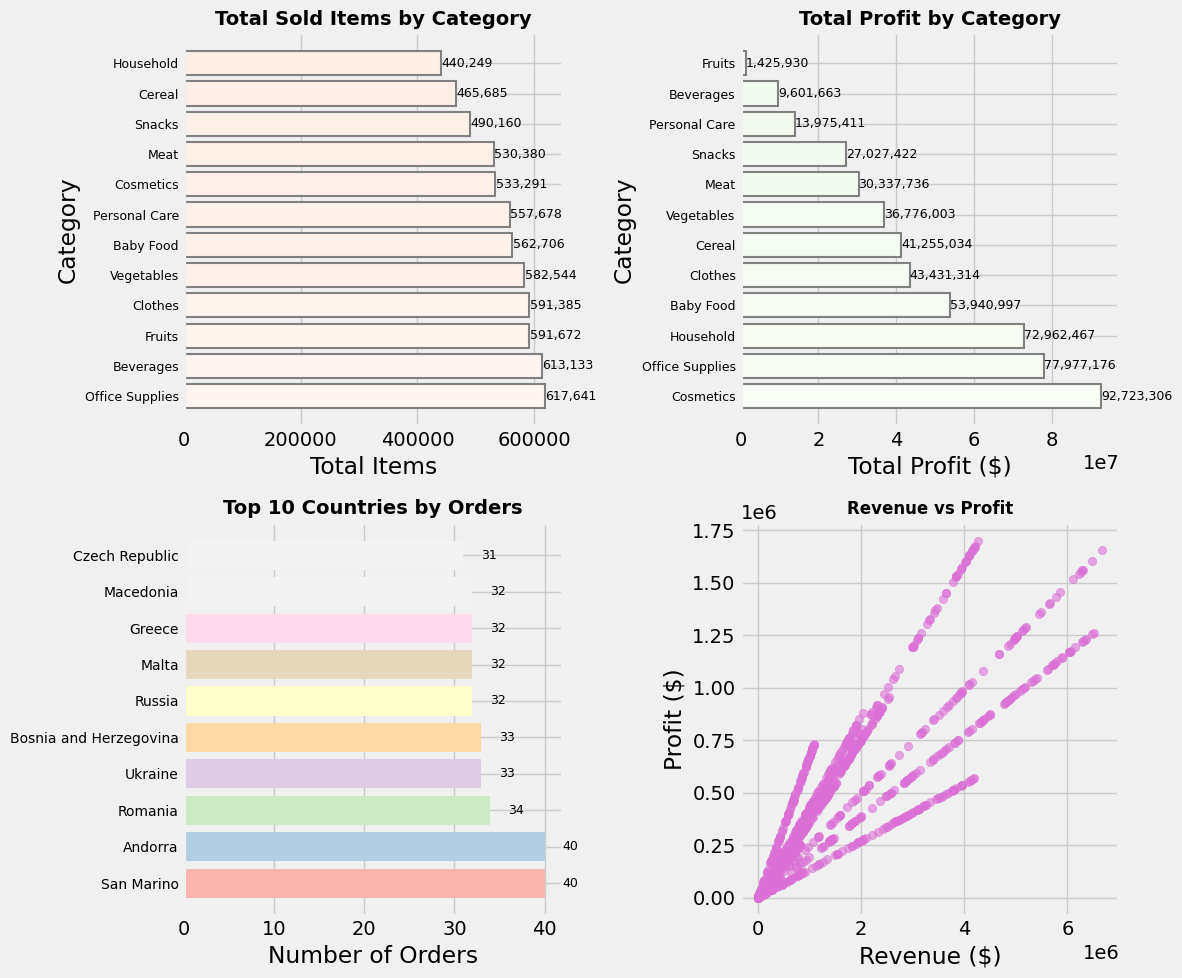

In [25]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

#Кількість продуктів в кожній категорії
sold_by_category = data.groupby("item_type")["units_sold"].sum().sort_values(ascending=False)
colors_cost = plt.cm.Reds(range(len(sold_by_category)))
bars1 = ax[0, 0].barh(sold_by_category.index, sold_by_category.values, color=colors_cost, edgecolor="grey", linewidth=1.5)
ax[0, 0].set_title("Total Sold Items by Category", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Total Items")
ax[0, 0].set_ylabel("Category")
ax[0, 0].tick_params(axis='y', labelsize=9)


for bar in bars1:
    ax[0, 0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                  f"{bar.get_width():,.0f}", va='center', ha='left', fontsize=9)

#Прибуток за категоріями
profit_by_category = data.groupby("item_type")["profit"].sum().sort_values(ascending=False)
colors_profit = plt.cm.Greens(range(len(profit_by_category)))
bars2 = ax[0, 1].barh(profit_by_category.index, profit_by_category.values, color=colors_profit, edgecolor="grey", linewidth=1.5)
ax[0, 1].set_title("Total Profit by Category", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Total Profit ($)")
ax[0, 1].set_ylabel("Category")
ax[0, 1].tick_params(axis='y', labelsize=9)
for bar in bars2:
    ax[0, 1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                  f"{bar.get_width():,.0f}", va='center', ha='left', fontsize=9)

#Топ-10 країн за кількістю замовлень
top_countries = data["country_name"].value_counts().head(10)
colors_countries = plt.cm.Pastel1(range(len(top_countries)))
bars3 = ax[1, 0].barh(top_countries.index, top_countries.values, color=colors_countries)
ax[1, 0].set_title("Top 10 Countries by Orders", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Number of Orders")
ax[1, 0].tick_params(axis='y', labelsize=10)

for bar in bars3:
    ax[1, 0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f"{bar.get_width()}",
                  va='center', ha='left', fontsize=9)

#Revenue vs Profit
ax[1, 1].scatter(data["revenue"], data["profit"], alpha=0.6, color="orchid")
ax[1, 1].set_title("Revenue vs Profit", fontsize=12, fontweight="bold")
ax[1, 1].set_xlabel("Revenue ($)")
ax[1, 1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()



Проаналізував дані графіків видно, що найбільш продаються товари категорії Office Supplies (продано 617641 одиницю товару). В топ по кількості проданих одиниць входить також Beverages (скоріш за все тому що має низьку ціну за одиницю), найменше продається товарів категорії Household.

Такі категорії як Cosmetics, Office Supplies та Household приносять найбільше доходу. В той час - категорії Fruits, Beverages найменш прибуткові.

Графік №3 показує кількість замовлень Топ-10 країн за загальними доходами.Найбільше замовлень роблять країни San Marino, Andorra, Romania. Але в цілому цифри замовлень не дуже відрізняються у топ країн.

Останній четвертий графік показує тенеденцію розподілу доходів та прибутків і вона прямолінійна, тобто при рості доходів також зростають і прибутки.

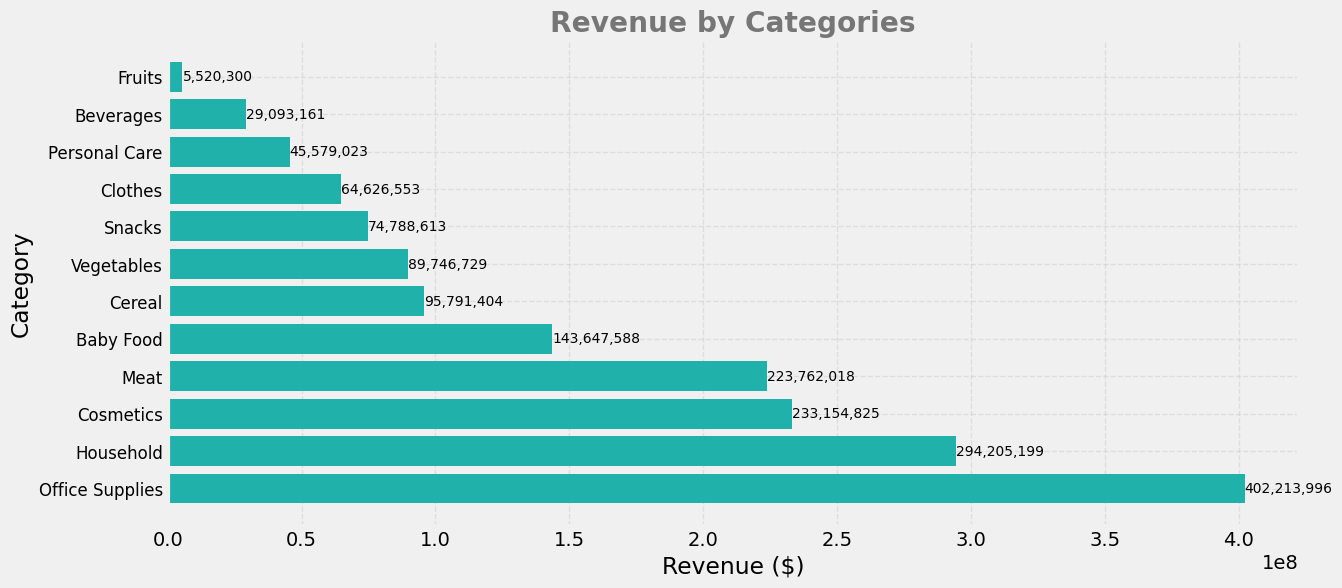

In [26]:
#Аналіз доходів в розрізі категорій
category_revenue = data.groupby("item_type")["revenue"].sum().sort_values(ascending=False)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(13, 6))

bars = plt.barh(category_revenue.index, category_revenue.values, color="lightseagreen")
plt.title("Revenue by Categories",fontweight="bold",
    color="dimgray",
    alpha=0.9,
    ha="center")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")
plt.yticks(fontsize=12)

for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10)
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.grid(axis='x', linestyle='--',alpha=0.5)
plt.show()


Найбільший дохід приносять категорії Office Supplies, Household, Cosmetics та Meat. Найменший дохід приносить категорія фруктів (через їх низьку ціну).

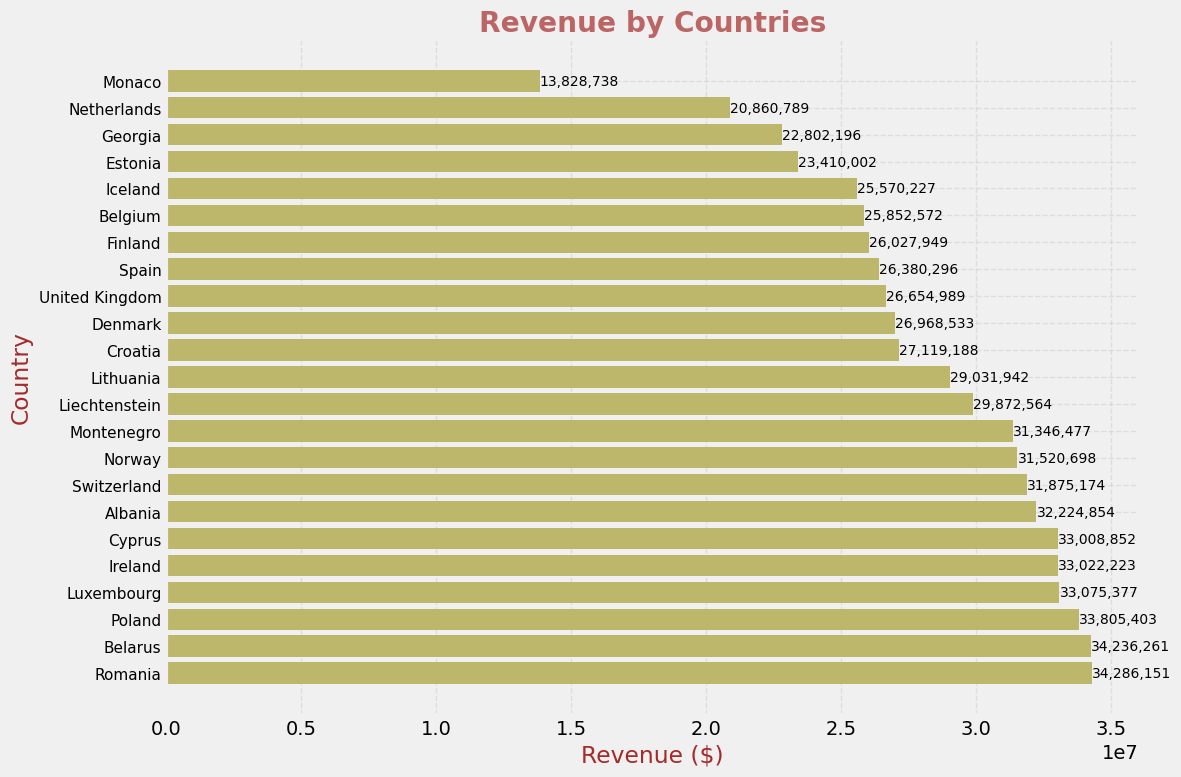

In [27]:
revenue_by_countries = data.groupby("country_name")["revenue"].sum().sort_values(ascending=False).reset_index()
filtered_countries = revenue_by_countries[revenue_by_countries["revenue"] < 35000000]

plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))


bars = plt.barh(filtered_countries["country_name"], filtered_countries["revenue"], color="darkkhaki")
plt.title("Revenue by Countries", fontweight="bold",
          color="brown", alpha=0.7)
plt.xlabel("Revenue ($)", color="brown")
plt.ylabel("Country", color="brown")
plt.yticks(fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()


Розділивши всі країни на 2 частини (менше та більше за медіанне значення доходів) можна побачити розподіл при сортуванні. В першій частині країн (з меншим медіанним доходом) лідерами є Румунія, Беларусь та Польща за доходами.

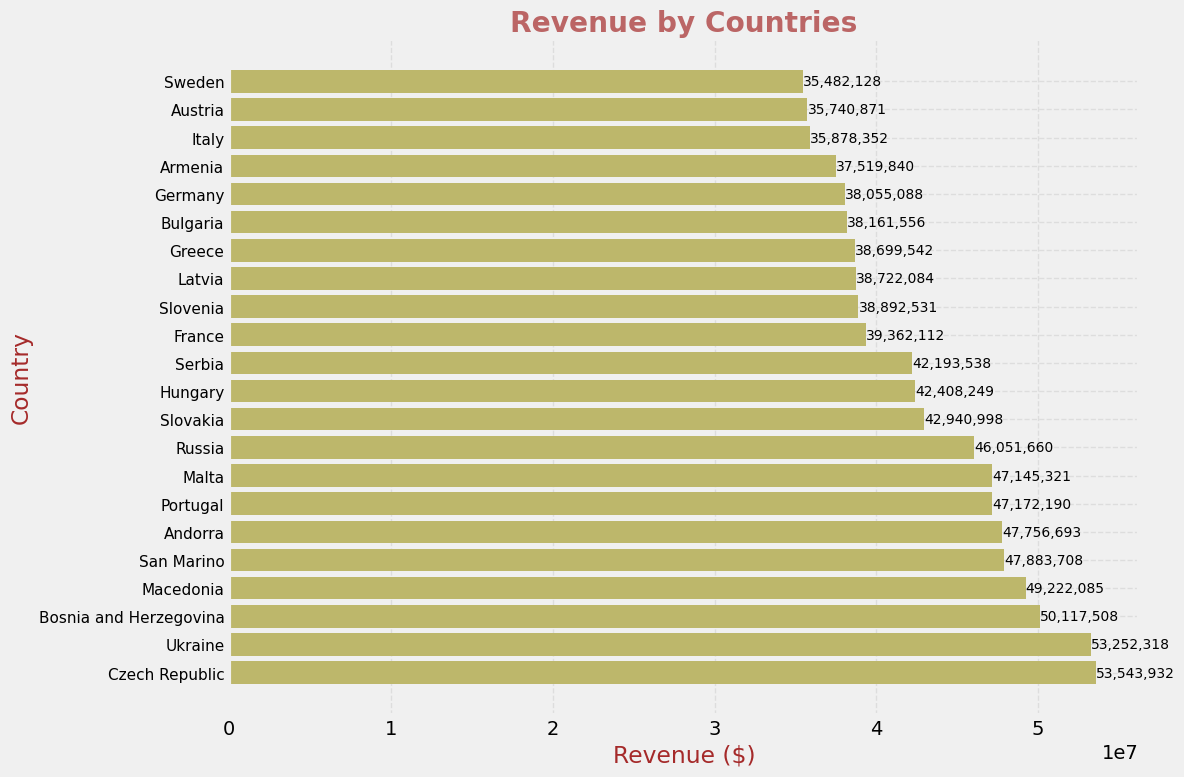

In [28]:
import matplotlib.pyplot as plt

revenue_by_countries = data.groupby("country_name")["revenue"].sum().sort_values(ascending=False).reset_index()
filtered_countries = revenue_by_countries[revenue_by_countries["revenue"] > 35000000]

plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))


bars = plt.barh(filtered_countries["country_name"], filtered_countries["revenue"], color="darkkhaki")
plt.title("Revenue by Countries", fontweight="bold",
          color="brown", alpha=0.7)
plt.xlabel("Revenue ($)", color="brown")
plt.ylabel("Country", color="brown")
plt.yticks(fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()


В другій частині країн (з більшим медіанним доходом) лідерами є Чехія, Україна  та Боснія та Герцеговіна за доходами.

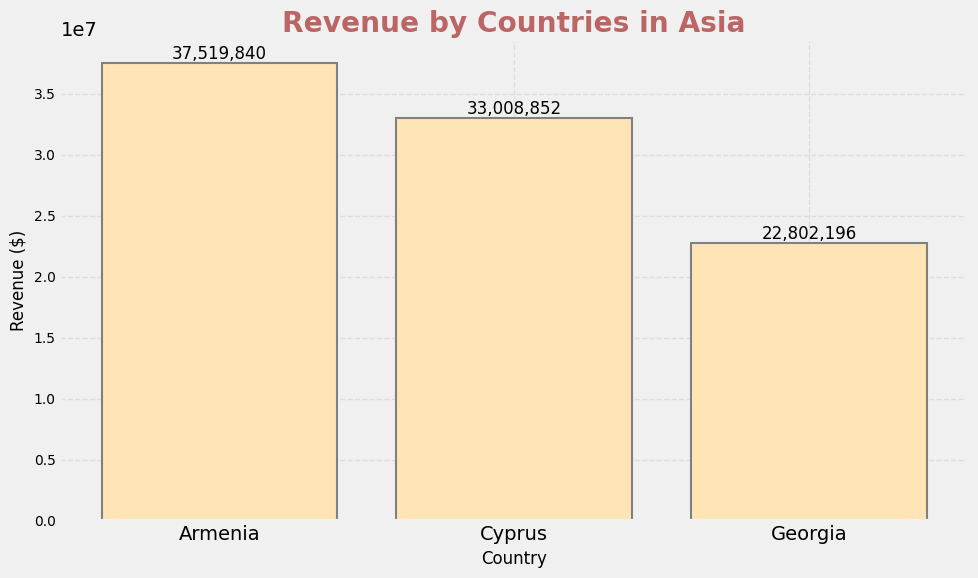

In [29]:
asia_countries = data[data["region"] == "Asia"]

revenue_by_countries = asia_countries.groupby("country_name")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))

bars = plt.bar(revenue_by_countries["country_name"], revenue_by_countries["revenue"], color="moccasin", edgecolor="grey", linewidth=1.5)
plt.title("Revenue by Countries in Asia", fontweight="bold", color="brown", alpha=0.7)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()

За доходами, аналізуючи країни Азії, лідер - Вірменія.

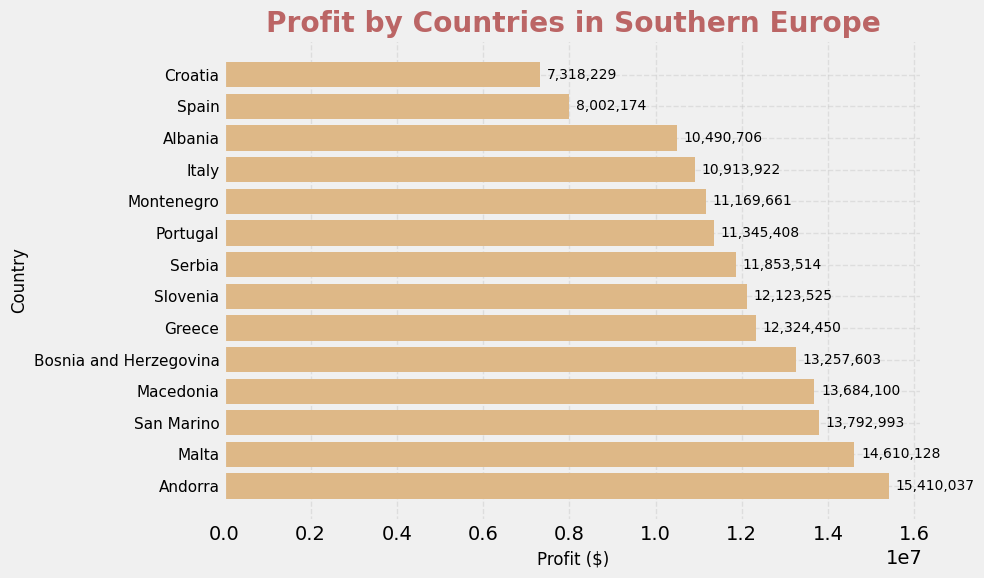

In [30]:

southern_europe_countries = data[data["sub_region"] == "Southern Europe"]
revenue_by_countries = southern_europe_countries.groupby("country_name")["profit"].sum().sort_values(ascending=False).reset_index()

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))

bars = plt.barh(revenue_by_countries["country_name"], revenue_by_countries["profit"], color="burlywood")
plt.title("Profit by Countries in Southern Europe", fontweight="bold", color="brown", alpha=0.7)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.yticks(fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

max_value = revenue_by_countries["profit"].max()
offset = max_value * 0.01

for bar in bars:
        plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()


Найбільш прибуткові країни Південої Європи - це Андора, Мальта, Сан Маріно (найбільш економіно розвинені). Найменший прибуток приносить Хорватія.

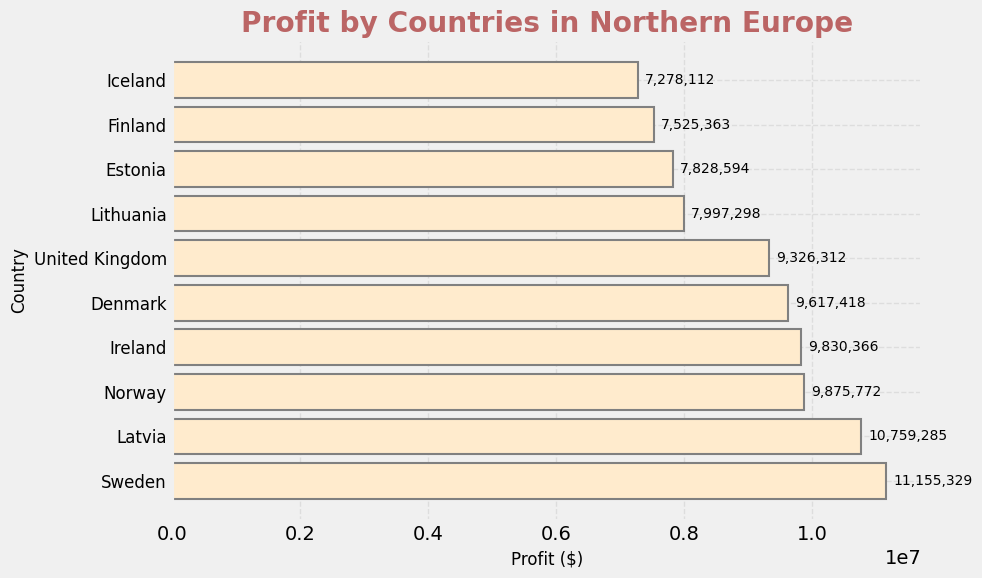

In [31]:
northern_europe_countries = data[data["sub_region"] == "Northern Europe"]

revenue_by_countries = northern_europe_countries.groupby("country_name")["profit"].sum().sort_values(ascending=False).reset_index()

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))

bars = plt.barh(revenue_by_countries["country_name"], revenue_by_countries["profit"], color="blanchedalmond", edgecolor="grey", linewidth=1.5)
plt.title("Profit by Countries in Northern Europe", fontweight="bold", color="brown", alpha=0.7)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

max_value = revenue_by_countries["profit"].max()
offset = max_value * 0.01

for bar in bars:
        plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Найбільш прибуткові країни Північної Європи - це Швеціяб Латвія та Норвегія.

Найменш прибуткові - Ісландія.

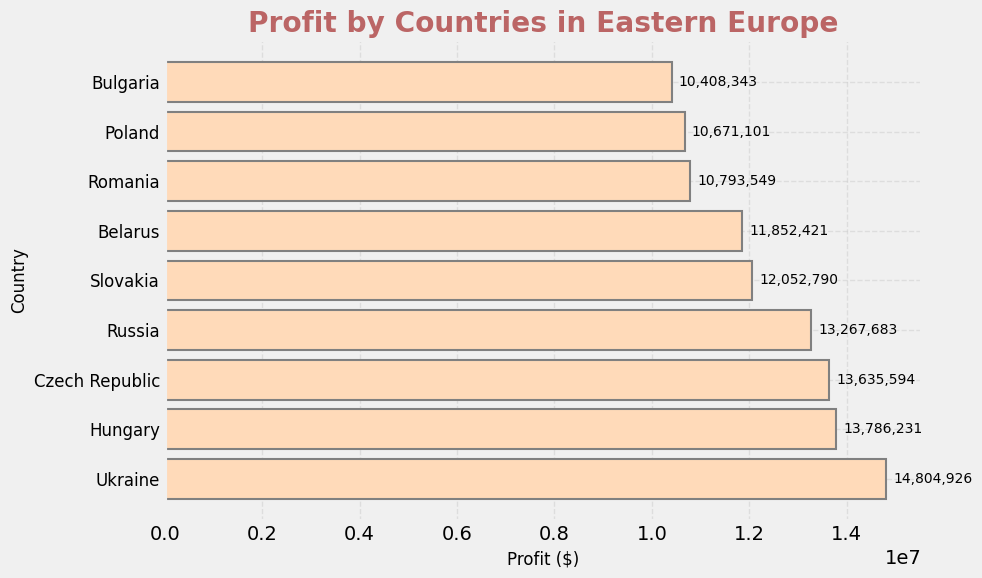

In [32]:
eastern_europe_countries = data[data["sub_region"] == "Eastern Europe"]

revenue_by_countries = eastern_europe_countries.groupby("country_name")["profit"].sum().sort_values(ascending=False).reset_index()

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))

bars = plt.barh(revenue_by_countries["country_name"], revenue_by_countries["profit"], color="peachpuff", edgecolor="grey", linewidth=1.5)
plt.title("Profit by Countries in Eastern Europe", fontweight="bold", color="brown", alpha=0.7)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

max_value = revenue_by_countries["profit"].max()
offset = max_value * 0.01

for bar in bars:
        plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Найбільшу прибутковість країн Східної Європи приносять такі країни як Україна, Угорщина та Чехія. Найменше - Болгарія.

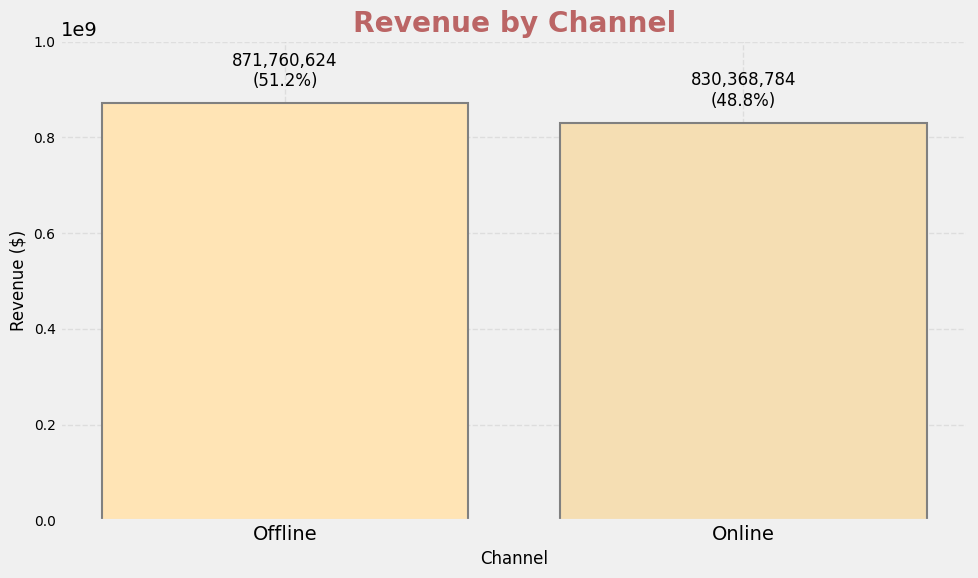

In [33]:
data["sales_channel"] = data["sales_channel"].replace("online", "Online")
revenue_by_channel = data.groupby("sales_channel")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))

bars = plt.bar(
    revenue_by_channel["sales_channel"],
    revenue_by_channel["revenue"],
    color=["moccasin", "wheat"],
    edgecolor="grey",
    linewidth=1.5
)

plt.title("Revenue by Channel", fontweight="bold", color="brown", alpha=0.7)
plt.xlabel("Channel", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)


max_value = revenue_by_channel["revenue"].max()
offset = max_value * 0.03
total = revenue_by_channel["revenue"].sum()


for bar in bars:
    value = bar.get_height()
    percent = value / total * 100

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + offset,
        f"{value:,.0f}\n({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.ylim(0, max_value * 1.15)
plt.tight_layout()
plt.show()


В загальному невелика різниця отримання доходів при здійсненні покупок Онлайн чи Офлайн. Покупки, зроблені Офлайн в магазині приносять трішки більше доходу.

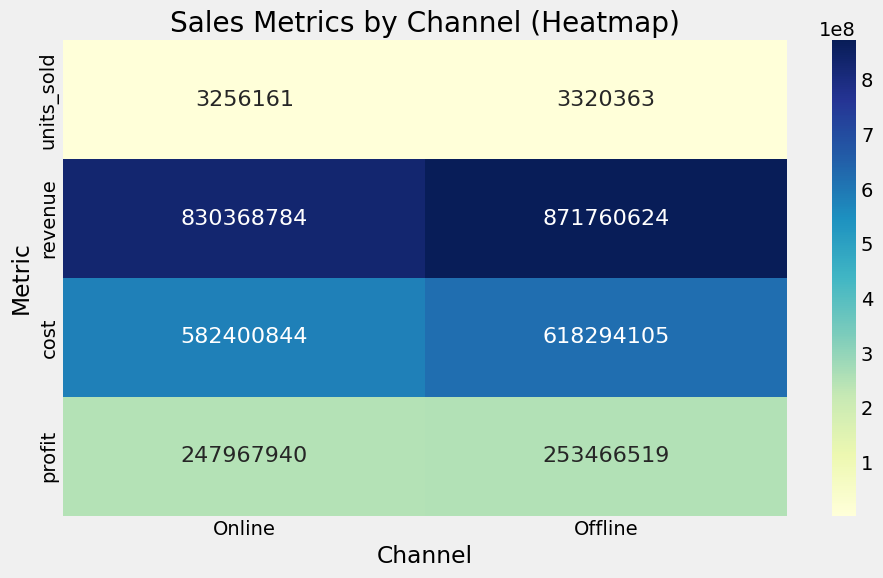

In [34]:
data["sales_channel"] = data["sales_channel"].str.capitalize()


category_grouped4 = data.groupby("sales_channel")[["units_sold", "revenue", "cost", "profit"]].sum().sort_values(by="units_sold", ascending=True)


plt.figure(figsize=(10, 6))
sns.heatmap(category_grouped4.T, annot=True, cmap="YlGnBu", fmt=".0f", annot_kws={"size":16})
plt.title("Sales Metrics by Channel (Heatmap)")
plt.xlabel("Channel")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()

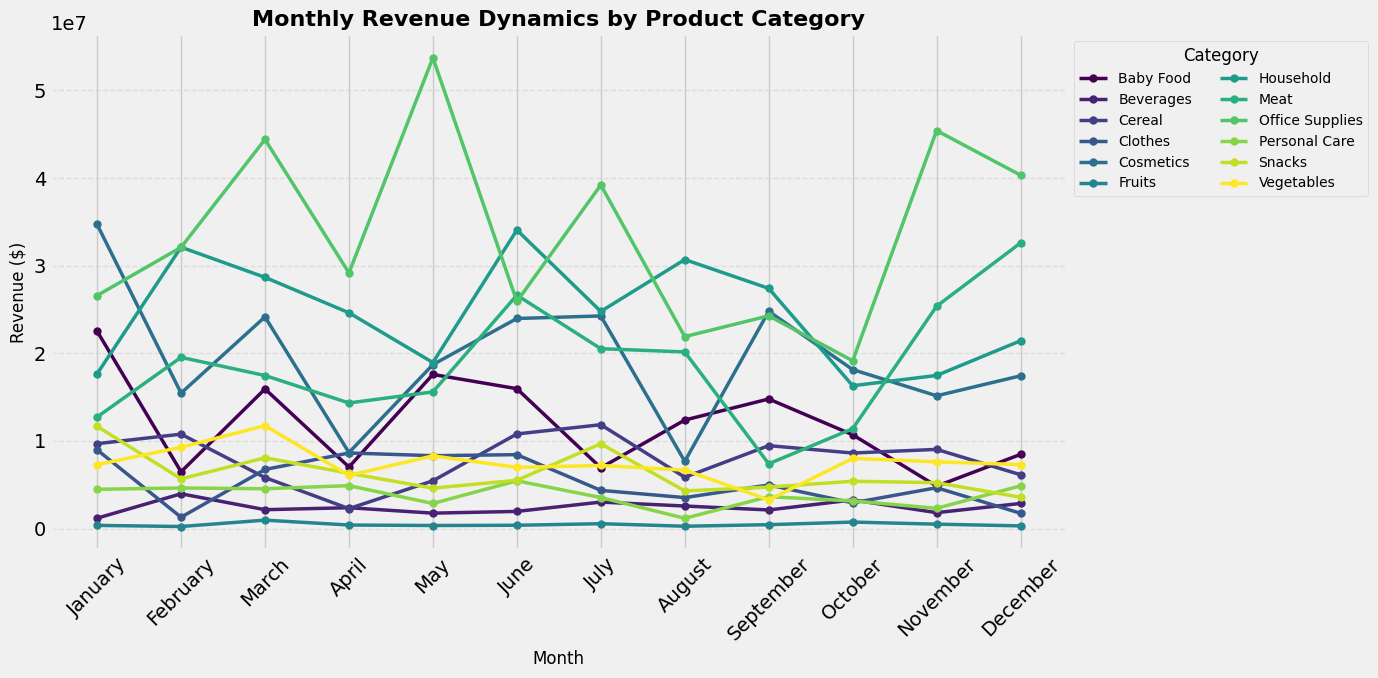

In [38]:
import calendar
import matplotlib.cm as cm

data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.month

monthly_sales = data.groupby(["month", "item_type"])["revenue"].sum().unstack().fillna(0)


num_categories = monthly_sales.shape[1]
colors = cm.viridis(np.linspace(0, 1, num_categories))

plt.style.use("fivethirtyeight")
plt.figure(figsize=(14, 7))


for i, category in enumerate(monthly_sales.columns):
    plt.plot(
        monthly_sales.index,
        monthly_sales[category],
        label=category,
        color=colors[i],
        linewidth=2.5,
        marker='o',
        markersize=5
    )


month_names = [calendar.month_name[i] for i in range(1, 13)]
plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)

plt.title("Monthly Revenue Dynamics by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)


plt.legend(title="Category", fontsize=10, title_fontsize=12, ncol=2, loc="upper left", bbox_to_anchor=(1,1))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Графік залежності доходів від категорій по місяцях показує, що продажі та дохід залежить від сезонності. Наприклад, товари категорії Office Supplies більше купують починаючи з квітня і закінчуючи кінцем літа, також є скачок в середині восени.
Речі купують більше на початку кожного сезону.
Фрукти та овочі однаково купують протягом всього року.

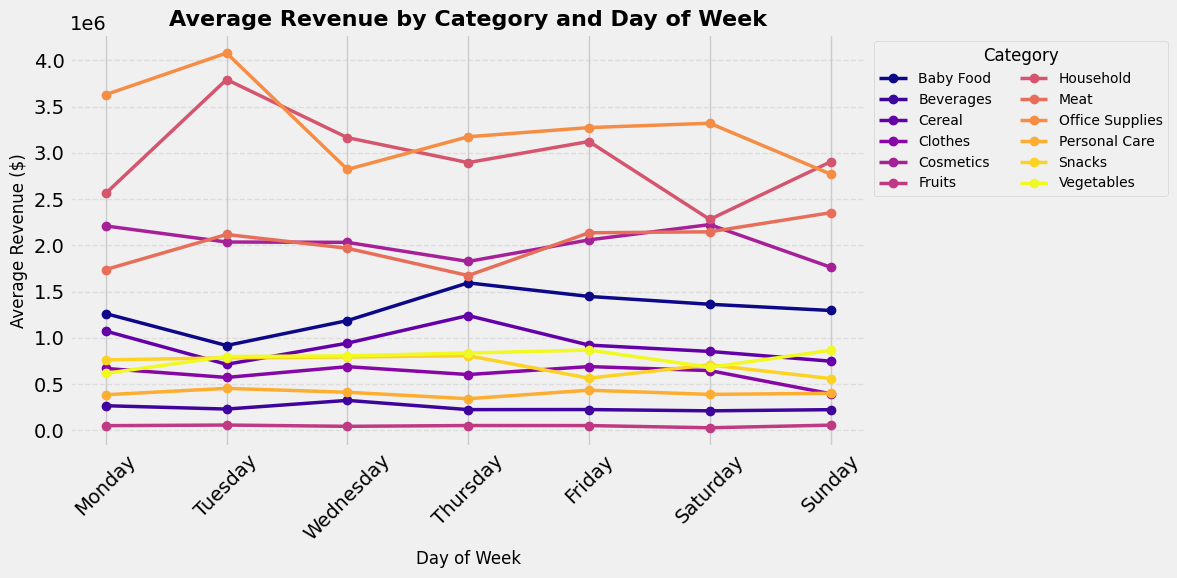

In [40]:

data["day_of_week"] = data["order_date"].dt.day_name()
weekly_sales = data.groupby(["day_of_week", "item_type"])["revenue"].mean().unstack().fillna(0)


num_categories = weekly_sales.shape[1]
colors = cm.plasma(np.linspace(0, 1, num_categories))

plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 6))


for i, category in enumerate(weekly_sales.columns):
    plt.plot(
        weekly_sales.index,
        weekly_sales[category],
        label=category,
        color=colors[i],
        linewidth=2.5,
        marker='o',
        markersize=6
    )


days = [calendar.day_name[i] for i in range(7)]
plt.xticks(ticks=range(7), labels=days, rotation=45)

plt.title("Average Revenue by Category and Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Revenue ($)", fontsize=12)


plt.legend(title="Category", fontsize=10, title_fontsize=12, ncol=2, loc="upper left", bbox_to_anchor=(1,1))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Аналізуючи графік розподілення категорій за їх доходами по днях можна зробити висновок, що деякі продукти можна вважати сезонними. Наприклад, товари категорії Office Supplies продаються частіше на початку тижня, це пов'язано із початком робочого часу у багатьох працівників. Така ж тенденція є у товарів категорії Household (найбільші продажі та доходи на початку тижня і спад ближче до вихідних). Але основні товари загалом не мають сезонної тижневої залежності.

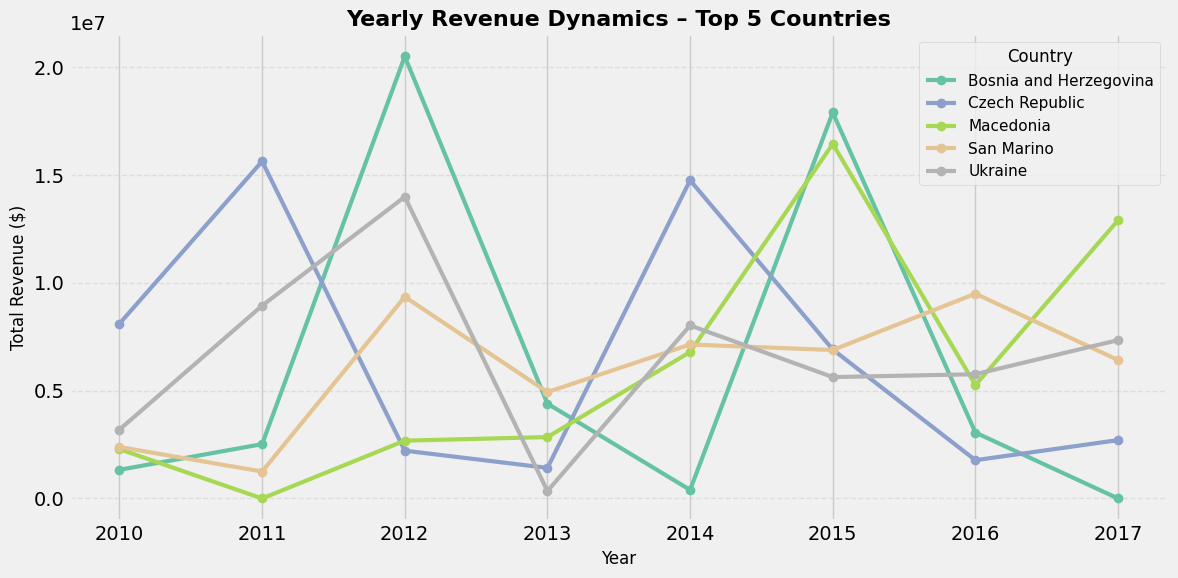

In [41]:
data["year"] = data["order_date"].dt.year

top5_countries = (
    data.groupby("country_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

#Фільтруємо тільки топ-5
top5_data = data[data["country_name"].isin(top5_countries)]

#Групуємо по роках та країнах
yearly_sales = (
    top5_data
    .groupby(["year", "country_name"])["revenue"]
    .sum()
    .unstack()
    .fillna(0)
)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 6))

# Кольори
colors = cm.Set2(np.linspace(0, 1, len(yearly_sales.columns)))

# Малюємо лінії
for i, country in enumerate(yearly_sales.columns):
    plt.plot(
        yearly_sales.index,
        yearly_sales[country],
        marker="o",
        linewidth=3,
        markersize=6,
        label=country,
        color=colors[i]
    )

plt.title("Yearly Revenue Dynamics – Top 5 Countries", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

plt.xticks(yearly_sales.index)
plt.legend(title="Country", fontsize=11, title_fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Графік показує піки та спади топ-5 найприбутковіших країн протягом всіх років.Така країна як Македонія показую найбільшу покупову спроможніть за остані роки. У Боснії та Герцеговіни є піки прибутковості в 2012 та 2015 роках. Сан Маріно - одна з найстабільніших країн згідно графіку.Чехія за останній рік показує спад прибутковості.

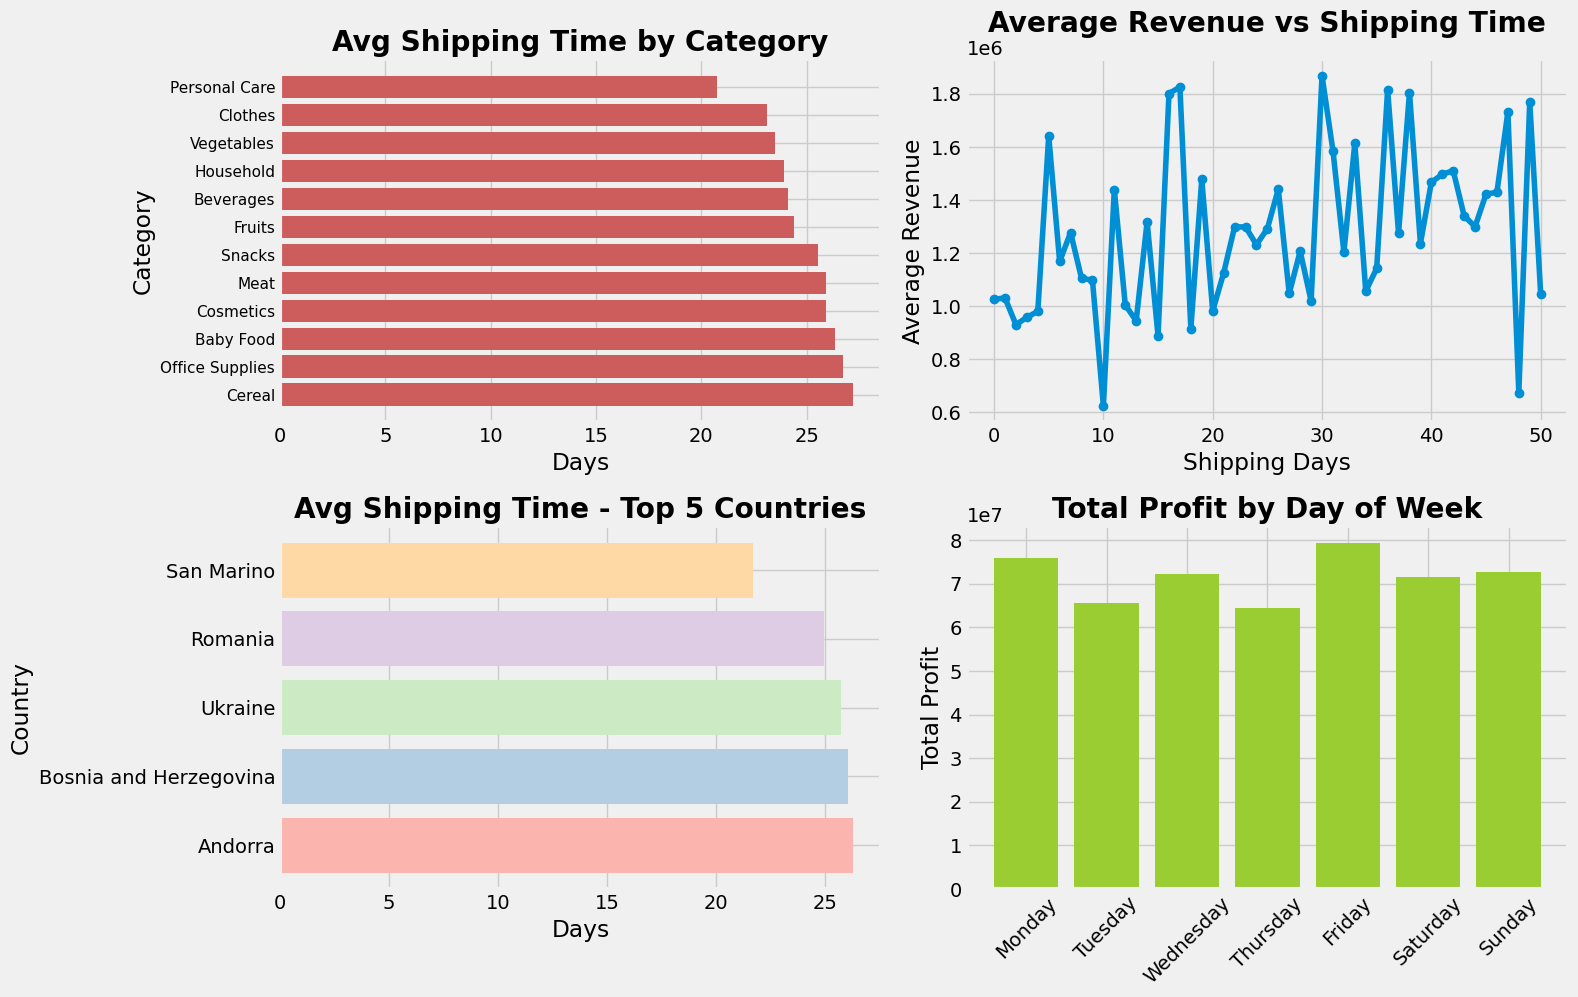

In [42]:
plt.style.use("fivethirtyeight")

data["order_date"] = pd.to_datetime(data["order_date"])
data["ship_date"]  = pd.to_datetime(data["ship_date"])
data["shipping_days"] = (data["ship_date"] - data["order_date"]).dt.days
data = data[data["shipping_days"] >= 0]

# День тижня
data["day_of_week"] = data["order_date"].dt.day_name()

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

avg_shipping_category = (
    data.groupby("item_type")["shipping_days"]
    .mean()
    .sort_values(ascending=False)
)

ax[0, 0].barh(avg_shipping_category.index,
              avg_shipping_category.values,
              color="indianred")

ax[0, 0].set_title("Avg Shipping Time by Category", fontweight="bold")
ax[0, 0].set_xlabel("Days")
ax[0, 0].set_ylabel("Category")
ax[0, 0].tick_params(axis='y', labelsize=11)


avg_revenue_by_shipping = (
    data.groupby("shipping_days")["revenue"]
    .mean()
)

ax[0, 1].plot(avg_revenue_by_shipping.index,
              avg_revenue_by_shipping.values,
              marker="o")

ax[0, 1].set_title("Average Revenue vs Shipping Time", fontweight="bold")
ax[0, 1].set_xlabel("Shipping Days")
ax[0, 1].set_ylabel("Average Revenue")


top5_countries = data["country_name"].value_counts().head(5).index

avg_shipping_country = (
    data[data["country_name"].isin(top5_countries)]
    .groupby("country_name")["shipping_days"]
    .mean()
    .sort_values(ascending=False)
)
colors_countries = plt.cm.Pastel1(range(len(top5_countries)))
ax[1, 0].barh(avg_shipping_country.index,
              avg_shipping_country.values,
              color=colors_countries)

ax[1, 0].set_title("Avg Shipping Time - Top 5 Countries", fontweight="bold")
ax[1, 0].set_xlabel("Days")
ax[1, 0].set_ylabel("Country")



profit_by_day = (
    data.groupby("day_of_week")["profit"]
    .sum()
)


days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
profit_by_day = profit_by_day.reindex(days_order)

ax[1, 1].bar(profit_by_day.index,
             profit_by_day.values,
             color="yellowgreen")

ax[1, 1].set_title("Total Profit by Day of Week", fontweight="bold")
ax[1, 1].set_ylabel("Total Profit")
ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Визначаємо які категорії мають найдовший середній час доставки. Найдовша доставка для таких категорій товарів як Baby Food, Office Supplies, Cereal.

Це дозволяє зрозуміти, як час доставки впливає на загальний дохід завдяки вирахованим даним раніше  і зробити висновок, що час доставки (інтервал часу між замовленням та його відвантаженням) не впливає на прибутковість.

Середній час доставки складає від 21-26 днів для топ-5 найприбутковіших  країн.

Просліджується невисока залежність від дня тижня на отримання прибутку: найбільший прибуток кампанія отримує в загальному у п'ятницю та в понеділок.



year            2010          2011          2012          2013          2014  \
region                                                                         
Asia    1.404036e+07  4.347440e+06  2.179092e+07  1.233149e+07  1.227657e+07   
Europe  1.882141e+08  2.098649e+08  2.457695e+08  1.630246e+08  2.046980e+08   

year            2015          2016          2017  
region                                            
Asia    1.476692e+07  6.243820e+06  7.533370e+06  
Europe  1.992201e+08  1.750343e+08  1.198274e+08  


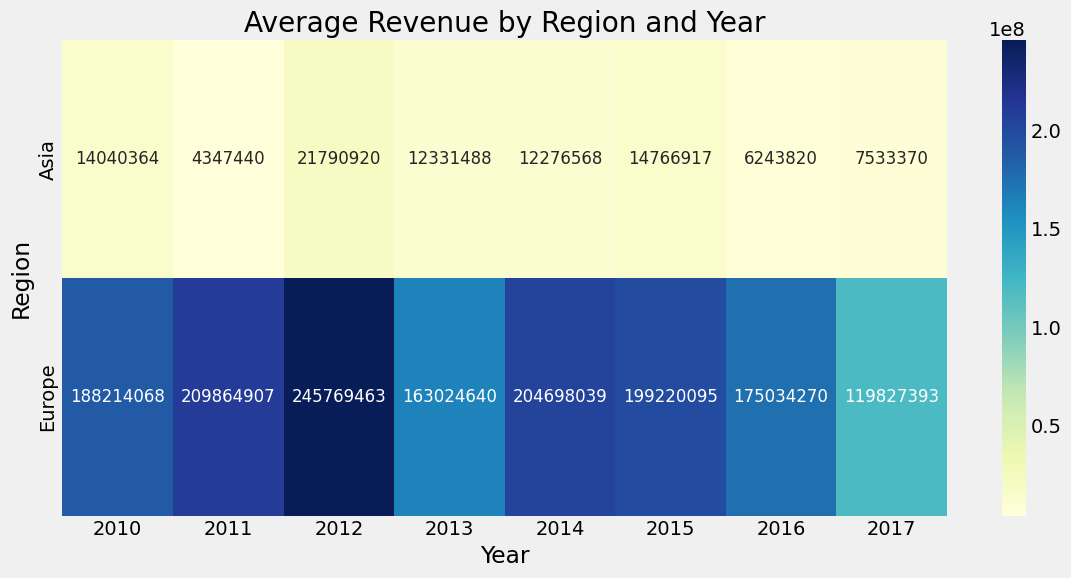

In [ ]:
pivot_table_revenue_by_regions = pd.pivot_table(data, values="revenue", index="region", columns="year", aggfunc="sum")
print(pivot_table_revenue_by_regions)

revenue_by_regions = data.groupby("region")["revenue"].sum()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table_revenue_by_regions, annot=True, fmt=",.0f", cmap="YlGnBu", annot_kws={"size":12})
plt.title("Total Revenue by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

